# Act 3 - Mô phỏng kịch bản nếu cắt khuyến mãi âm

**Câu hỏi trung tâm:** Nếu cắt các chương trình có đóng góp lợi nhuận gộp âm, kết quả tài chính thay đổi thế nào dưới các giả định nhu cầu quay lại khác nhau?

Dự báo tuyến tính chỉ đóng vai trò cảnh báo rủi ro; phần quyết định chính là mô phỏng kịch bản tài chính khi cắt các chương trình âm lợi nhuận.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"


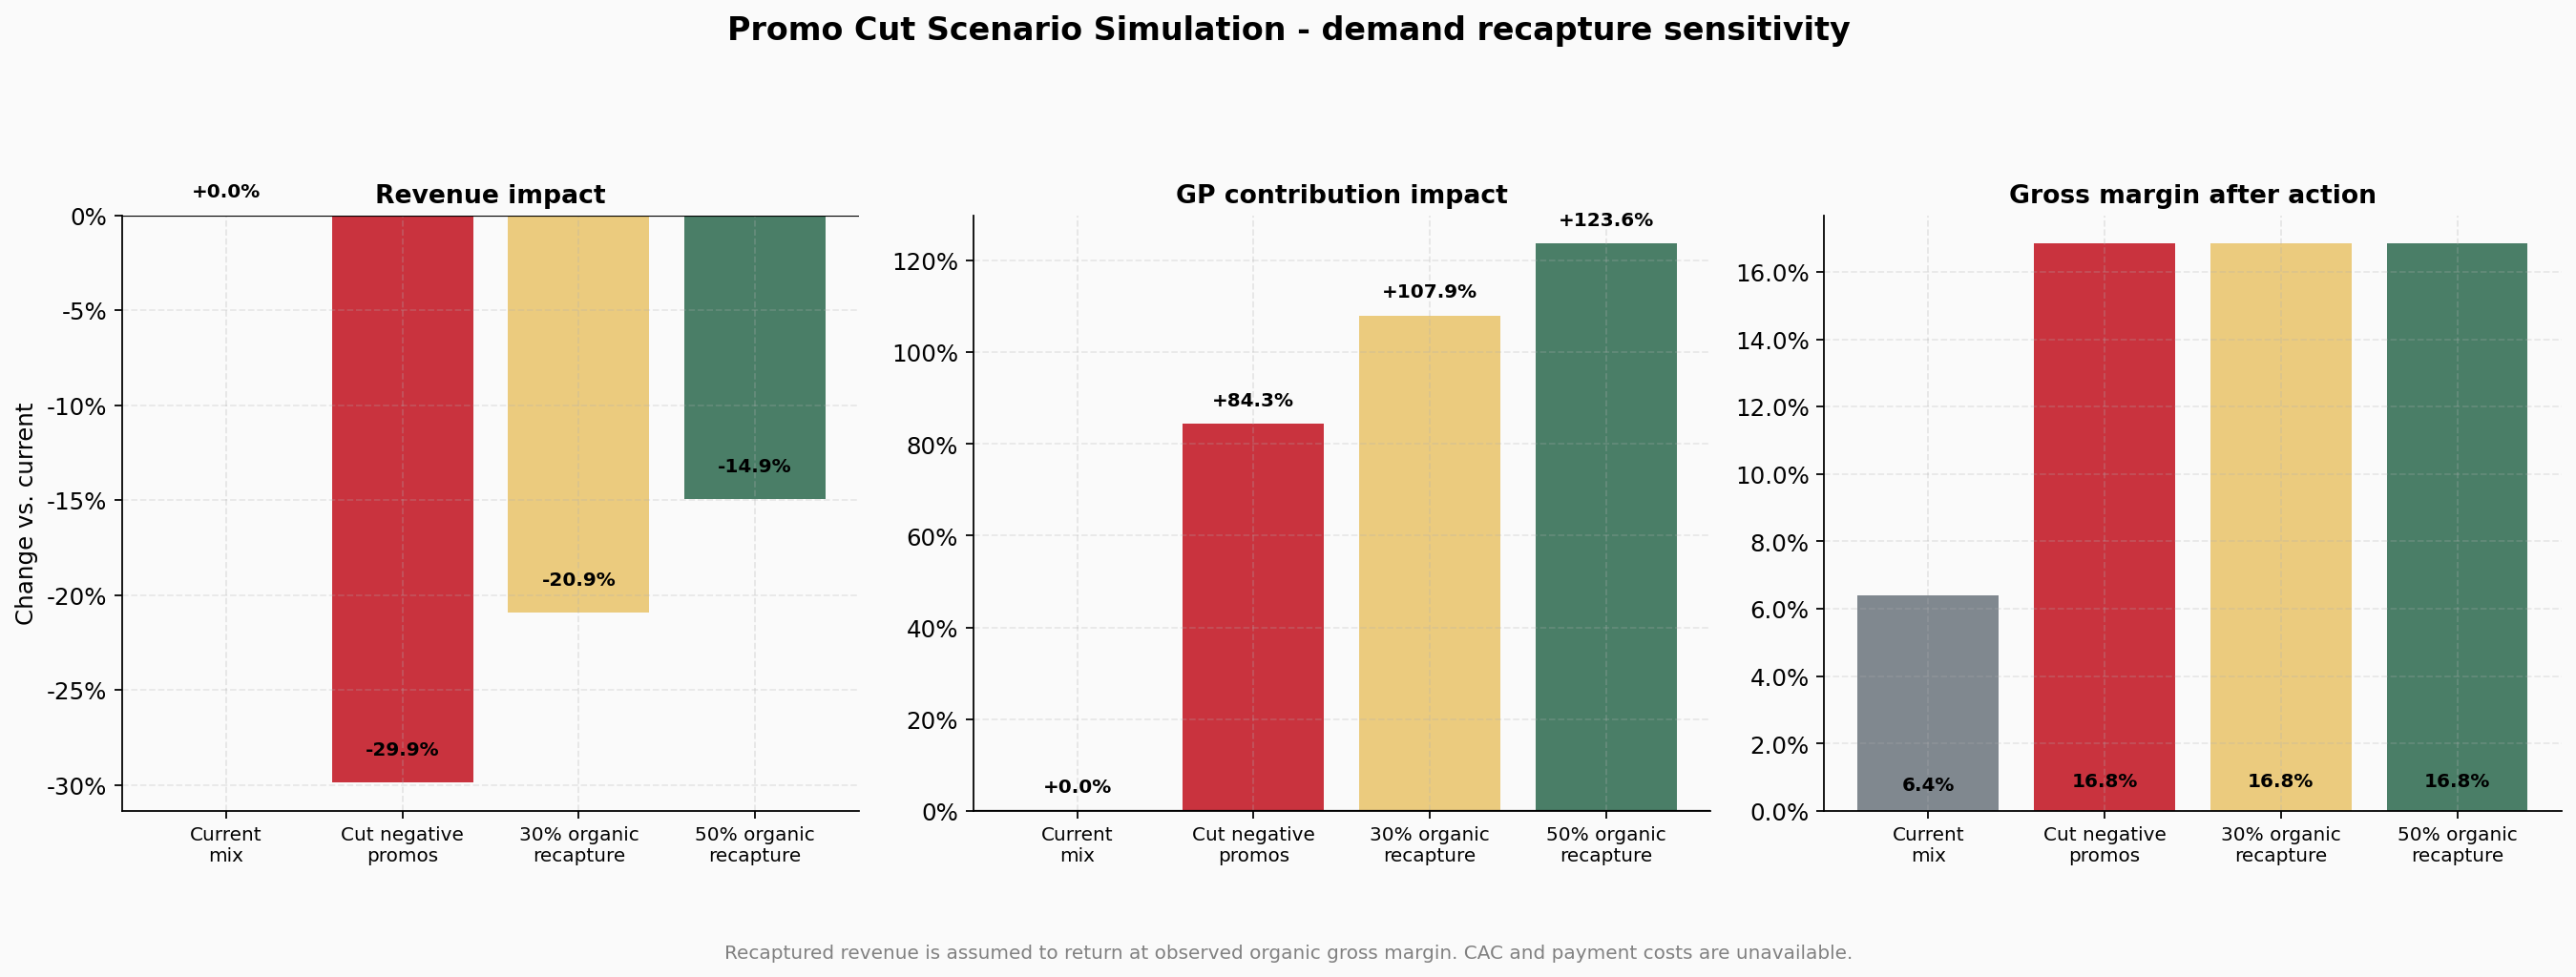

In [2]:
display(Image(str(CHARTS / "chart5_margin_scenario_simulation.png"), width=950))


In [3]:
scenario = pd.read_csv(TABLES / "promo_cut_scenario_table.csv")
scenario_display = scenario.copy()
scenario_display["assumption"] = scenario_display["assumption"].replace({
    "All promotions continue": "Giữ nguyên toàn bộ khuyến mãi",
    "0% of removed promo revenue returns at organic margin": "0% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
    "30% of removed promo revenue returns at organic margin": "30% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
    "50% of removed promo revenue returns at organic margin": "50% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
})
scenario_display = scenario_display.rename(columns={
    "scenario": "kich_ban",
    "recapture_rate": "ty_le_nhu_cau_quay_lai",
    "revenue": "doanh_thu",
    "gp_contribution": "dong_gop_loi_nhuan_gop",
    "gross_margin": "bien_loi_nhuan_gop",
    "revenue_impact_pct": "tac_dong_doanh_thu_pct",
    "gp_impact_pct": "tac_dong_loi_nhuan_gop_pct",
    "assumption": "gia_dinh",
})
display(scenario_display)
forecast = pd.read_csv(TABLES / "margin_forecast_table.csv")
forecast_display = forecast[forecast["quarter"].isin(["2026Q4", "2027Q4"])].rename(columns={
    "quarter": "quy",
    "date": "ngay",
    "forecast": "du_bao",
    "lower_1sd": "can_duoi_1sd",
    "upper_1sd": "can_tren_1sd",
})
display(forecast_display)


,kich_ban,ty_le_nhu_cau_quay_lai,doanh_thu,dong_gop_loi_nhuan_gop,bien_loi_nhuan_gop,tac_dong_doanh_thu_pct,tac_dong_loi_nhuan_gop_pct,gia_dinh
0,Current mix,NaN,1.568087e+10,1.004011e+09,0.064028,0.000000,0.000000,Giữ nguyên toàn bộ khuyến mãi
1,Cut negative promos,0.0,1.099504e+10,1.850890e+09,0.168339,-29.882465,84.349626,0% doanh thu khuyến mãi bị cắt quay lại ở biên...
2,Cut + 30% organic recapture,0.3,1.240079e+10,2.087532e+09,0.168339,-20.917725,107.919284,30% doanh thu khuyến mãi bị cắt quay lại ở biê...
3,Cut + 50% organic recapture,0.5,1.333795e+10,2.245294e+09,0.168339,-14.941232,123.632390,50% doanh thu khuyến mãi bị cắt quay lại ở biê...


,quy,ngay,du_bao,can_duoi_1sd,can_tren_1sd
15,2026Q4,2026-10-01,-0.129175,-8.979894,8.721543
19,2027Q4,2027-10-01,-0.691601,-9.542319,8.159118


## Phân tích

Hiện trạng tạo **15,680,869,265 VND doanh thu**, **1,004,010,930 VND đóng góp lợi nhuận gộp sau hoàn tiền và phí vận chuyển**, tương ứng biên lợi nhuận gộp **6.4%**.

Trong kịch bản thận trọng nhất **0% nhu cầu quay lại**, cắt **50 chương trình âm lợi nhuận gộp** làm doanh thu giảm còn **10,995,039,053 VND** (**-29.9%**), nhưng đóng góp lợi nhuận gộp tăng lên **1,850,890,392 VND** (**+84.3%**) và biên lợi nhuận gộp tăng lên **16.8%**.

Nếu **30% doanh thu khuyến mãi bị mất quay lại ở biên lợi nhuận tự nhiên**, doanh thu còn **12,400,788,117 VND** (**-20.9%**) và đóng góp lợi nhuận gộp tăng **+107.9%**. Với **50% nhu cầu quay lại**, doanh thu còn **13,337,954,159 VND** (**-14.9%**) và đóng góp lợi nhuận gộp tăng **+123.6%**.

Dự báo tuyến tính chỉ là cảnh báo rủi ro, không phải quy tắc ra quyết định. Xu hướng gần đây giảm khoảng **0.1 điểm %/quý**, biên lợi nhuận bốn quý gần nhất chỉ **4.4%**. Dự báo **Q4/2026 là -0.1%** với khoảng dao động **-9.0% đến 8.7%**; **Q4/2027 là -0.7%** với khoảng dao động **-9.5% đến 8.2%**. Khoảng dao động quá rộng nên không đủ để ra quyết định một mình.

**Kết luận Act 3:** Mô phỏng kịch bản là bằng chứng dự báo chính: cắt khuyến mãi âm vẫn cải thiện lợi nhuận gộp ngay cả khi không có nhu cầu quay lại.
